## Imports

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import osmnx as ox
import networkx as nx

## Project Setup

In [74]:
SEED=42
np.random.seed(SEED)
random.seed(SEED)

GRID_SIZE=5
START=(0,0)
GOAL=(4,4)
OBSTACLES={(1,1),(2,1),(3,3)}

ACTIONS={
    0: (-1,0),
    1: (1,0),
    2: (0,-1),
    3: (0,1)
}

N_ACTIONS=len(ACTIONS)

## Environment

In [75]:
class GridRouteEnv:
    def __init__(self, grid_size, start, goal, obstacles):
        self.grid_size=grid_size
        self.start=start
        self.goal=goal
        self.obstacles=set(obstacles)
        self.state= None

    def reset(self):
        self.state=self.start
        return self.state
        
    def step(self, action):
        r,c=self.state
        dr, dc=ACTIONS[action]
        candidate=(r+dr, c+dc)

        if candidate[0] < 0 or candidate[0] >= self.grid_size or candidate[1] < 0 or candidate[1] >= self.grid_size:
            next_state=self.state
            reward=-1
            done=False
            self.state=next_state
            return next_state, reward, done
        
        if candidate in self.obstacles:
            next_state=self.state
            reward=-5
            done=False
            self.state=next_state
            return next_state, reward, done

        if candidate==self.goal:
            next_state=candidate
            reward=20
            done=True
            self.state=next_state
            return next_state, reward, done

        next_state = candidate
        reward = -1
        done = False
        self.state = next_state
        return next_state, reward, done


env=GridRouteEnv(GRID_SIZE, START, GOAL, OBSTACLES)
s=env.reset()
print("Start:", s)

for t in range(8):
    action=random.randint(0, N_ACTIONS -1)
    nextstate, r, d=env.step(action)
    print(f"try={t}, action={action}, nextstate={nextstate}, reward={r}, done={d}")
    if d:
        break

Start: (0, 0)
try=0, action=0, nextstate=(0, 0), reward=-1, done=False
try=1, action=0, nextstate=(0, 0), reward=-1, done=False
try=2, action=2, nextstate=(0, 0), reward=-1, done=False
try=3, action=1, nextstate=(1, 0), reward=-1, done=False
try=4, action=1, nextstate=(2, 0), reward=-1, done=False
try=5, action=1, nextstate=(3, 0), reward=-1, done=False
try=6, action=0, nextstate=(2, 0), reward=-1, done=False
try=7, action=0, nextstate=(1, 0), reward=-1, done=False


## Q-Learning

In [76]:
def update_q(q_table, state, action, reward, next_state, alpha, gamma):
    current_q=q_table[state[0], state[1], action]
    best_next_q= np.max(q_table[next_state[0], next_state[1], :])
    target=reward + gamma * best_next_q
    new_q=current_q + alpha * (target-current_q)
    q_table[state[0], state[1], action]=new_q


## Epsilon-Greedy

In [77]:
def choose_action(state, q_table, epsilon):
    u=random.random()
    if u<epsilon:
        return random.randint(0, N_ACTIONS-1)
    else:
        return int(np.argmax(q_table[state[0], state[1], :]))

## Training Loop

In [78]:
EPISODES=1000
MAX_STEPS=100
ALPHA=0.1
GAMMA=0.95
EPSILON=1.0
EPSILON_MIN=0.05
EPSILON_DECAY=0.995

q_table=np.zeros((GRID_SIZE, GRID_SIZE, N_ACTIONS))
episode_rewards=[]

for ep in range(EPISODES):
    state=env.reset()
    total_reward=0

    for step in range(MAX_STEPS):
        action=choose_action(state, q_table, EPSILON)
        next_state, reward, done = env.step(action)

        update_q(q_table, state, action, reward, next_state, ALPHA, GAMMA)

        state=next_state
        total_reward+=reward

        if done:
            break

    episode_rewards.append(total_reward)
    EPSILON=max(EPSILON_MIN, EPSILON * EPSILON_DECAY)

## Quick Training 

Final epsilon:  0.05
Mean reward (last 50 episodes):  12.5


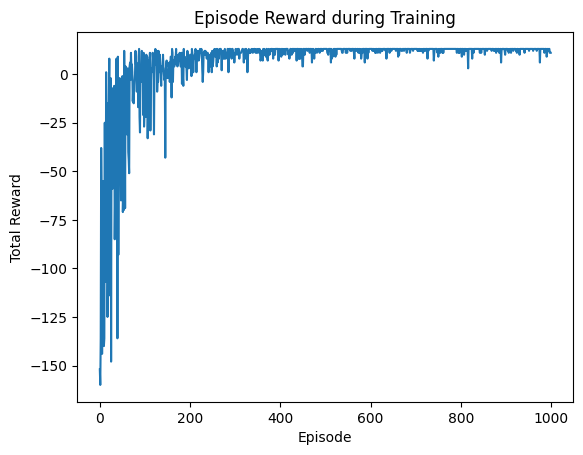

In [79]:
print("Final epsilon: ", EPSILON)
print("Mean reward (last 50 episodes): ", np.mean(episode_rewards[-50:]))

plt.plot(episode_rewards)
plt.title("Episode Reward during Training")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

## Greedy Evaluation

##

In [80]:
def run_greedy_route(env, q_table, max_steps=50):
    state=env.reset()
    path=[state]
    total_reward=0

    for step in range(max_steps):
        action=int(np.argmax(q_table[state[0], state[1], :]))
        next_state, reward, done = env.step(action)
        path.append(next_state)
        total_reward+=reward
        state=next_state

        if done:
            return path, total_reward, True
    
    return path, total_reward, False

path, score, reached=run_greedy_route(env, q_table)
print("Reached goal: ", reached)
print("Path length: ", len(path)-1)
print("Path: ", path)
print("Score: ", score)

Reached goal:  True
Path length:  8
Path:  [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]
Score:  13


## Graph Loading (Eindhoven)

In [81]:
SEED=42
np.random.seed(SEED)
random.seed(SEED)
GRAPH_PATH="data\eindhoven_drive_processed.graphml"
G=ox.load_graphml(GRAPH_PATH)
print("Nodes: ", len(G.nodes))
print("Edges: ", len(G.edges))


Nodes:  4424
Edges:  10555


## Comparison with EDA coordinates

In [82]:
origin=(51.446915422770466, 5.503542626552148)
destination=(51.45128576098493, 5.479564794710434)

start_node=ox.distance.nearest_nodes(G, X=origin[1], Y=origin[0])
goal_node=ox.distance.nearest_nodes(G, X=destination[1], Y=destination[0])

print("Starting Node:", start_node)
print("Goal Node:", goal_node)

route_time=nx.shortest_path(
    G,
    source=start_node,
    target=goal_node,
    weight="travel_time"
)

def route_total(G, route, weight):
    total=0.0
    for u, v in zip(route[:-1], route[1:]):
        edge_data=G.get_edge_data(u,v)
        best=min(edge_data.values(), key=lambda d: d.get(weight, float("inf")))
        total+=best.get(weight, 0.0)

    return total

total_time_sec=route_total(G, route_time, "travel_time")
total_dist_m=route_total(G,route_time, "length")

print("Route found: ", len(route_time), "nodes")
print("Total time (min):", round(total_time_sec/60, 2))
print("Total length (km):", round(total_dist_m/1000, 2))
    

Starting Node: 42650318
Goal Node: 42660544
Route found:  29 nodes
Total time (min): 4.98
Total length (km): 4.02


## Plotting

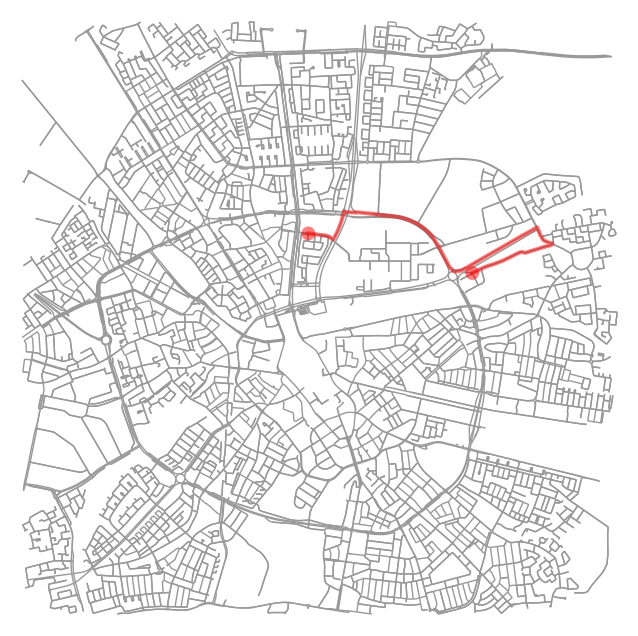

In [83]:
fig, ax = ox.plot_graph_route(
    G,
    route_time,
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
    route_color="red"
)

## Q-Learning on Eindhoven Subgraph 


In [84]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

try:
    G
except NameError:
    GRAPH_PATH = "data/eindhoven_drive_processed.graphml"
    G = ox.load_graphml(GRAPH_PATH)

if not all("travel_time" in d for _, _, _, d in G.edges(keys=True, data=True)):
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)

origin = (51.446915422770466, 5.503542626552148)
destination = (51.45128576098493, 5.479564794710434)

# Start small, then expand until the exact full-graph destination node is included.
SUBGRAPH_CUTOFF_M = 3000
CUTOFF_STEP_M = 500
MAX_CUTOFF_M = 12000

center_node = ox.distance.nearest_nodes(G, X=origin[1], Y=origin[0])
goal_full = ox.distance.nearest_nodes(G, X=destination[1], Y=destination[0])

G_len = ox.convert.to_digraph(G, weight="length")
cutoff_m = SUBGRAPH_CUTOFF_M

while True:
    reachable = nx.single_source_dijkstra_path_length(
        G_len,
        center_node,
        cutoff=cutoff_m,
        weight="length"
    )
    sub_nodes = set(reachable.keys())

    if goal_full in sub_nodes:
        break
    if cutoff_m >= MAX_CUTOFF_M:
        raise ValueError(
            f"Could not include full-graph goal node {goal_full} within MAX_CUTOFF_M={MAX_CUTOFF_M}."
        )

    cutoff_m += CUTOFF_STEP_M

G_sub_multi = G.subgraph(sub_nodes).copy()
G_sub = ox.convert.to_digraph(G_sub_multi, weight="travel_time")

start_node_sub = ox.distance.nearest_nodes(G_sub, X=origin[1], Y=origin[0])
goal_node_sub = goal_full

print("Full graph:", len(G.nodes), "nodes,", len(G.edges), "edges")
print("Subgraph cutoff used (m):", cutoff_m)
print("Subgraph (MultiDiGraph):", len(G_sub_multi.nodes), "nodes,", len(G_sub_multi.edges), "edges")
print("Subgraph (DiGraph):", len(G_sub.nodes), "nodes,", len(G_sub.edges), "edges")
print("Start node:", start_node_sub)
print("Goal node (full-graph exact):", goal_node_sub)
print("Goal in subgraph:", goal_node_sub in G_sub.nodes)



Full graph: 4424 nodes, 10555 edges
Subgraph cutoff used (m): 4000
Subgraph (MultiDiGraph): 1077 nodes, 2474 edges
Subgraph (DiGraph): 1077 nodes, 2438 edges
Start node: 42650318
Goal node (full-graph exact): 42660544
Goal in subgraph: True


In [85]:
class RoadQLearningEnv:
    def __init__(self, graph, goal_node):
        self.G = graph
        self.goal = goal_node

        self.nodes = list(self.G.nodes)
        self.node_to_idx = {n: i for i, n in enumerate(self.nodes)}
        self.idx_to_node = {i: n for n, i in self.node_to_idx.items()}

        self.out_actions = {}
        max_out = 0
        for n in self.nodes:
            outs = []
            for nbr in self.G.successors(n):
                travel_time = float(self.G[n][nbr].get("travel_time", 1.0))
                outs.append((nbr, travel_time))
            self.out_actions[n] = outs
            max_out = max(max_out, len(outs))

        self.max_actions = max_out
        self.state = None

        G_rev = self.G.reverse(copy=False)
        self.reachable_to_goal = set(nx.descendants(G_rev, self.goal)) | {self.goal}

    def reset(self, start_node=None):
        if start_node is None:
            candidates = [
                n for n in self.nodes
                if n != self.goal and len(self.out_actions[n]) > 0 and n in self.reachable_to_goal
            ]
            self.state = random.choice(candidates)
        else:
            self.state = start_node
        return self.node_to_idx[self.state]

    def valid_actions(self, state_idx):
        node = self.idx_to_node[state_idx]
        return list(range(len(self.out_actions[node])))

    def step(self, action_idx):
        node = self.state
        actions = self.out_actions[node]

        if action_idx < 0 or action_idx >= len(actions):
            return self.node_to_idx[node], -10.0, False

        next_node, travel_time = actions[action_idx]
        reward = -(travel_time / 10.0)
        done = next_node == self.goal

        if done:
            reward += 100.0

        self.state = next_node
        return self.node_to_idx[next_node], reward, done


def epsilon_greedy(q_table, state_idx, valid_actions, epsilon):
    if random.random() < epsilon:
        return random.choice(valid_actions)

    values = q_table[state_idx, valid_actions]
    return valid_actions[int(np.argmax(values))]



Final epsilon: 0.05
Training success rate: 0.509
Mean reward (last 100): -175.922


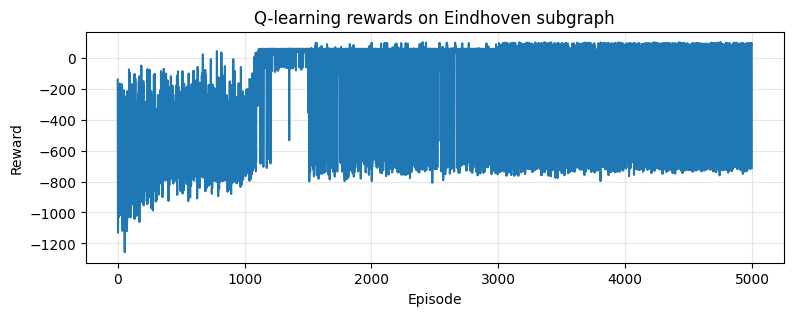

In [86]:
env_sub = RoadQLearningEnv(G_sub, goal_node_sub)
q_table_sub = np.zeros((len(env_sub.nodes), env_sub.max_actions), dtype=np.float32)

EPISODES_SUB = 5000
MAX_STEPS_SUB = 350
ALPHA_SUB = 0.1
GAMMA_SUB = 0.99
EPSILON_SUB = 1.0
EPS_MIN_SUB = 0.05
EPS_DECAY_SUB = 0.998

episode_rewards_sub = []
success_count_sub = 0

for ep in range(EPISODES_SUB):
    if ep < 1500:
        state = env_sub.reset(start_node=start_node_sub)
    elif ep < 3000 and random.random() < 0.7:
        state = env_sub.reset(start_node=start_node_sub)
    else:
        state = env_sub.reset()

    total_reward = 0.0
    visited = {env_sub.idx_to_node[state]}
    reached = False

    for _ in range(MAX_STEPS_SUB):
        valid = env_sub.valid_actions(state)
        if not valid:
            total_reward -= 20.0
            break

        action = epsilon_greedy(q_table_sub, state, valid, EPSILON_SUB)
        next_state, reward, done = env_sub.step(action)

        next_valid = env_sub.valid_actions(next_state)
        best_next_q = np.max(q_table_sub[next_state, next_valid]) if (not done and next_valid) else 0.0
        q_table_sub[state, action] += ALPHA_SUB * (
            reward + GAMMA_SUB * best_next_q - q_table_sub[state, action]
        )

        state = next_state
        total_reward += reward

        current_node = env_sub.idx_to_node[state]
        if current_node in visited:
            total_reward -= 2.0
        visited.add(current_node)

        if done:
            reached = True
            break

    EPSILON_SUB = max(EPS_MIN_SUB, EPSILON_SUB * EPS_DECAY_SUB)
    episode_rewards_sub.append(total_reward)
    success_count_sub += int(reached)

print("Final epsilon:", round(EPSILON_SUB, 4))
print("Training success rate:", round(success_count_sub / EPISODES_SUB, 3))
print("Mean reward (last 100):", round(float(np.mean(episode_rewards_sub[-100:])), 3))

plt.figure(figsize=(9, 3))
plt.plot(episode_rewards_sub)
plt.title("Q-learning rewards on Eindhoven subgraph")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True, alpha=0.3)
plt.show()



Q reached goal: True
Q route nodes: 35 | time (min): 7.16
SP route nodes: 29 | time (min): 4.98


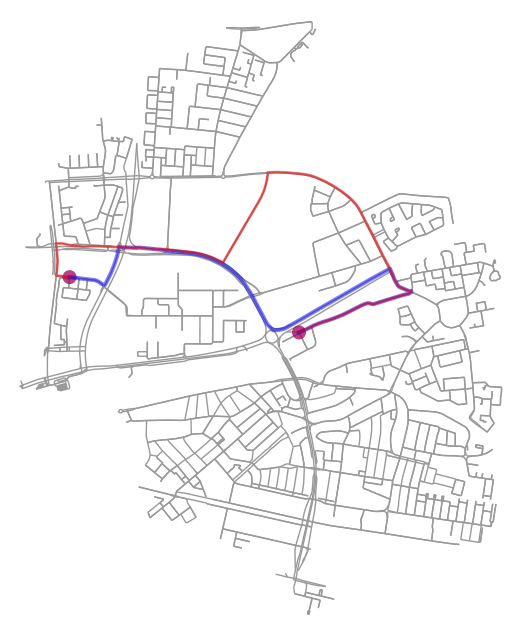

In [87]:
def route_total_digraph(graph, route, weight):
    total = 0.0
    for u, v in zip(route[:-1], route[1:]):
        total += float(graph[u][v].get(weight, 0.0))
    return total

state = env_sub.reset(start_node=start_node_sub)
q_route_sub = [start_node_sub]
seen_nodes = {start_node_sub}

for _ in range(300):
    valid = env_sub.valid_actions(state)
    if not valid:
        break

    action = valid[int(np.argmax(q_table_sub[state, valid]))]
    next_state, _, done = env_sub.step(action)
    next_node = env_sub.idx_to_node[next_state]
    q_route_sub.append(next_node)

    if next_node in seen_nodes:
        break
    seen_nodes.add(next_node)

    state = next_state
    if done:
        break

sp_route_sub = nx.shortest_path(
    G_sub,
    source=start_node_sub,
    target=goal_node_sub,
    weight="travel_time"
)

q_time_sec = route_total_digraph(G_sub, q_route_sub, "travel_time")
sp_time_sec = route_total_digraph(G_sub, sp_route_sub, "travel_time")

print("Q reached goal:", q_route_sub[-1] == goal_node_sub)
print("Q route nodes:", len(q_route_sub), "| time (min):", round(q_time_sec / 60.0, 2))
print("SP route nodes:", len(sp_route_sub), "| time (min):", round(sp_time_sec / 60.0, 2))

try:
    G_plot = G_sub_multi
except NameError:
    G_plot = G_sub

if not isinstance(G_plot, nx.MultiDiGraph):
    G_plot = nx.MultiDiGraph(G_plot)

fig, ax = ox.plot_graph_routes(
    G_plot,
    [sp_route_sub, q_route_sub],
    route_colors=["blue", "red"],
    route_linewidths=[3, 2],
    node_size=0,
    bgcolor="white"
)